In [1]:
# SWYNEX Task 2 — Exploratory Data Analysis

## Sample Superstore Dataset

#This project performs exploratory data analysis on the cleaned Sample Superstore dataset completed during Task 1.

### Objectives
# Analyze sales and profit
#- Identify trends and patterns
#- Detect potential anomalies
#- Create visualizations
#- Generate actionable business insights

### Tools
#- Python
#- Pandas
#- NumPy
#- Matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("cleaned_superstore.csv")

In [4]:
df.shape

(9977, 13)

In [5]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9977
Columns: 13


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1013.4+ KB


In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000
mean,55154.964117,230.148801,3.790719,0.156278,28.689832
std,32058.266816,623.721432,2.226657,0.206455,234.457848
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.300000,2.000000,0.000000,1.726200
50%,55901.000000,54.816000,3.000000,0.200000,8.671000
75%,90008.000000,209.970000,5.000000,0.200000,29.372000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
average_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
average_profit = df["Profit"].mean()
median_profit = df["Profit"].median()
total_quantity = df["Quantity"].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Average Sales:", round(average_sales, 2))
print("Median Sales:", round(median_sales, 2))
print("Average Profit:", round(average_profit, 2))
print("Median Profit:", round(median_profit, 2))
print("Total Quantity Sold:", total_quantity)

Total Sales: 2296194.59
Total Profit: 286238.45
Average Sales: 230.15
Median Sales: 54.82
Average Profit: 28.69
Median Profit: 8.67
Total Quantity Sold: 37820


In [10]:
profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


In [11]:
category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False)

category_analysis

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145451.9773,6939
Furniture,741305.3133,18421.8137,8020
Office Supplies,718735.2440,122364.6608,22861


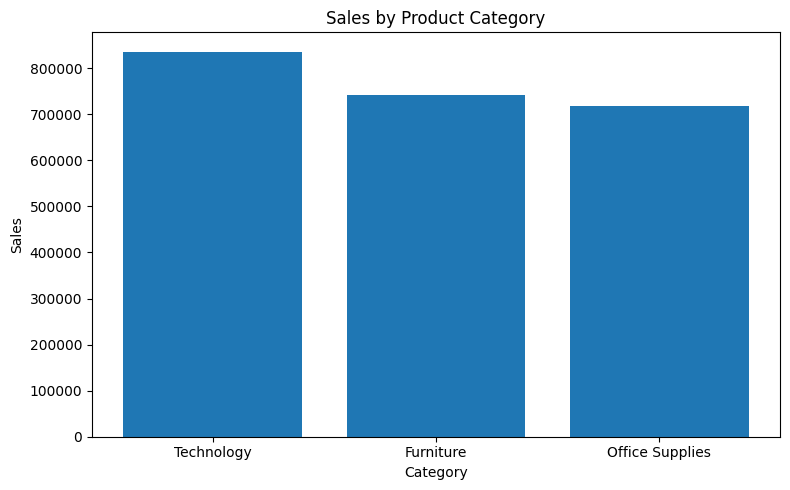

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis.index,
    category_analysis["Sales"]
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

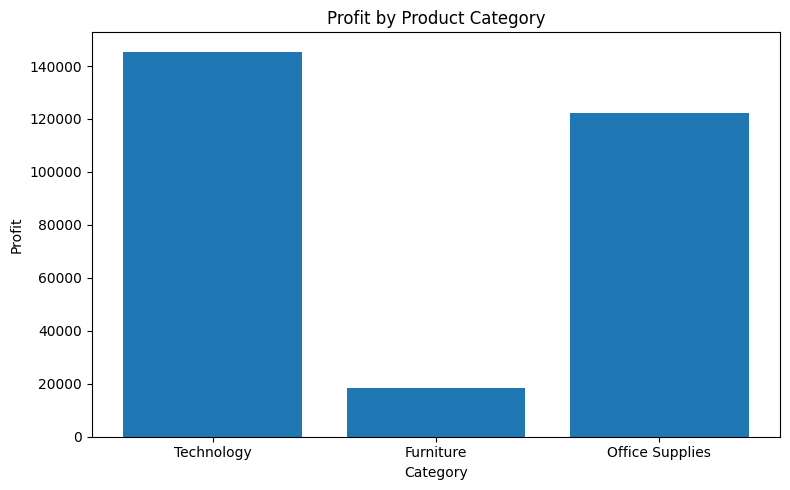

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis.index,
    category_analysis["Profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [14]:
region_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False)

region_analysis

,Sales,Profit,Quantity
Region,,,
West,725255.6365,108328.8371,12234
East,678435.1960,91506.3092,10609
Central,500782.8528,39653.8752,8768
South,391720.9050,46749.4303,6209


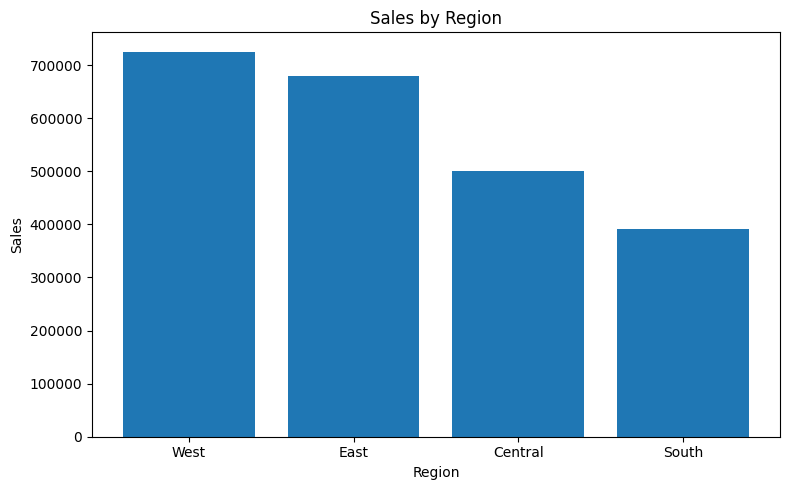

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis.index,
    region_analysis["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [16]:
segment_analysis = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False)

segment_analysis

,Sales,Profit,Quantity
Segment,,,
Consumer,1.160832e+06,134004.4705,19497
Corporate,7.060701e+05,91954.9798,11591
Home Office,4.292927e+05,60279.0015,6732


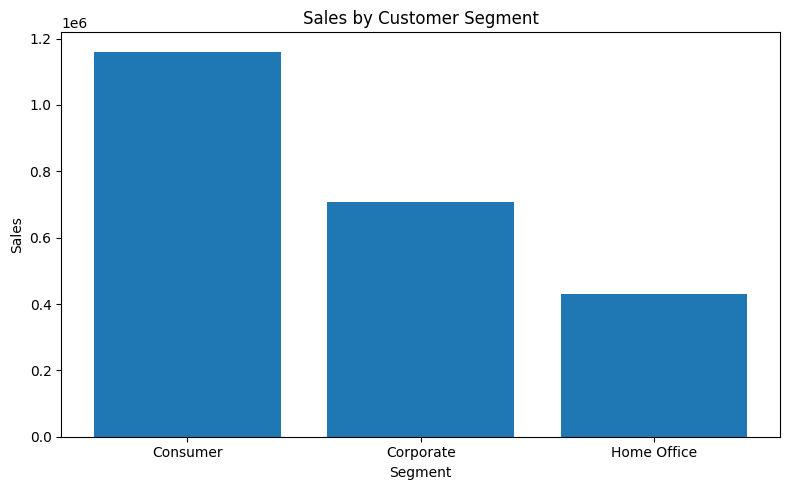

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_analysis.index,
    segment_analysis["Sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [18]:
subcategory_analysis = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Profit", ascending=False)

subcategory_analysis

,Sales,Profit,Quantity
Sub-Category,,,
Copiers,149528.0300,55617.8249,234
Phones,330007.0540,44513.7306,3289
Accessories,167380.3180,41935.6649,2976
Paper,78224.1420,33944.2395,5144
Binders,203409.1690,30228.0003,5971
Chairs,327777.7610,26567.1278,2351
Storage,223843.6080,21278.8264,3158
Appliances,107532.1610,18138.0054,1729
Furnishings,91683.0240,13052.7230,3560


In [19]:
subcategory_analysis.head(5)

,Sales,Profit,Quantity
Sub-Category,,,
Copiers,149528.030,55617.8249,234
Phones,330007.054,44513.7306,3289
Accessories,167380.318,41935.6649,2976
Paper,78224.142,33944.2395,5144
Binders,203409.169,30228.0003,5971


In [20]:
subcategory_analysis.tail(5)

,Sales,Profit,Quantity
Sub-Category,,,
Machines,189238.6310,3384.7569,440
Fasteners,3024.2800,949.5182,914
Supplies,46673.5380,-1189.0995,647
Bookcases,114879.9963,-3472.5560,868
Tables,206964.5320,-17725.4811,1241


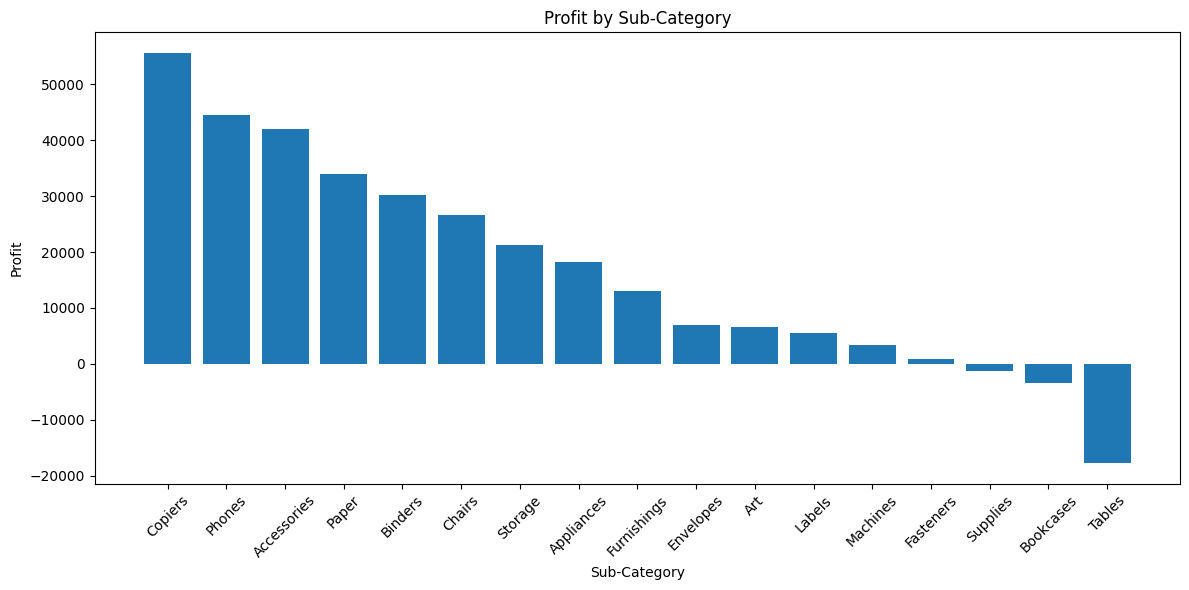

In [21]:
plt.figure(figsize=(12,6))

plt.bar(
    subcategory_analysis.index,
    subcategory_analysis["Profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

correlation = df["Discount"].corr(df["Profit"])

print("Discount-Profit Correlation:", round(correlation, 3))

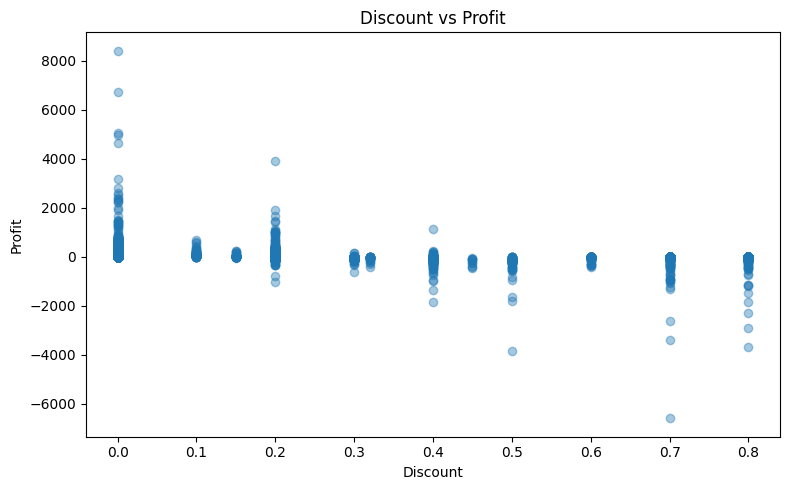

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [23]:
sales_threshold = df["Sales"].quantile(0.99)

high_sales = df[df["Sales"] > sales_threshold]

print("99th percentile sales:", round(sales_threshold, 2))
print("Number of high-sales transactions:", len(high_sales))

99th percentile sales: 2485.91
Number of high-sales transactions: 100


In [24]:
high_sales.sort_values("Sales", ascending=False).head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
2696,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.480,6,0.5,-1811.0784
6817,Standard Class,Corporate,United States,Lafayette,Indiana,47905,Central,Technology,Copiers,17499.950,5,0.0,8399.9760
8139,First Class,Consumer,United States,Seattle,Washington,98115,West,Technology,Copiers,13999.960,4,0.0,6719.9808
2622,First Class,Home Office,United States,New York City,New York,10024,East,Technology,Copiers,11199.968,4,0.2,3919.9888
4186,Standard Class,Consumer,United States,Newark,Delaware,19711,East,Technology,Copiers,10499.970,3,0.0,5039.9856
9025,Standard Class,Consumer,United States,Detroit,Michigan,48205,Central,Office Supplies,Binders,9892.740,13,0.0,4946.3700
4095,Standard Class,Consumer,United States,Minneapolis,Minnesota,55407,Central,Office Supplies,Binders,9449.950,5,0.0,4630.4755
4273,Standard Class,Corporate,United States,Lakewood,New Jersey,8701,East,Technology,Machines,9099.930,7,0.0,2365.9818
8474,Second Class,Consumer,United States,Arlington,Virginia,22204,South,Technology,Machines,8749.950,5,0.0,2799.9840
6416,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19120,East,Technology,Copiers,8399.976,4,0.4,1119.9968


In [25]:
large_losses = df[df["Profit"] < df["Profit"].quantile(0.01)]

print("Number of unusually large-loss transactions:", len(large_losses))

Number of unusually large-loss transactions: 100


In [26]:
large_losses.sort_values("Profit").head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
7760,Standard Class,Consumer,United States,Lancaster,Ohio,43130,East,Technology,Machines,4499.985,5,0.7,-6599.9780
683,Same Day,Corporate,United States,Burlington,North Carolina,27217,South,Technology,Machines,7999.980,4,0.5,-3839.9904
9757,Standard Class,Consumer,United States,San Antonio,Texas,78207,Central,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3010,Standard Class,Home Office,United States,Louisville,Colorado,80027,West,Technology,Machines,2549.985,5,0.7,-3399.9800
4986,Standard Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
3150,First Class,Consumer,United States,Newark,Ohio,43055,East,Technology,Machines,1799.994,2,0.7,-2639.9912
5305,First Class,Consumer,United States,Houston,Texas,77095,Central,Office Supplies,Binders,1525.188,6,0.8,-2287.7820
9622,Second Class,Consumer,United States,Concord,North Carolina,28027,South,Furniture,Tables,4297.644,13,0.4,-1862.3124
1198,Standard Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Binders,1088.792,4,0.8,-1850.9464
2696,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.480,6,0.5,-1811.0784


In [27]:
loss_making_subcategories = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

loss_making_subcategories

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5526.3820
Art,6524.6118
Envelopes,6964.1767
Furnishings,13052.7230


In [28]:
loss_making_subcategories[
    loss_making_subcategories < 0
]

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995


In [29]:
discount_analysis = df.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Transactions=("Profit", "count")
).sort_index()

discount_analysis

,Sales,Profit,Quantity,Transactions
Discount,,,,
0.00,1.087277e+06,320841.4365,18230,4787
0.10,5.436935e+04,9029.1770,373,94
0.15,2.755852e+04,1418.9915,198,52
0.20,7.645049e+05,90306.6070,13649,3653
0.30,1.029453e+05,-10357.2186,847,226
0.32,1.449346e+04,-2391.1377,105,27
0.40,1.164178e+05,-23057.0504,786,206
0.45,5.484974e+03,-2493.1111,45,11
0.50,5.891854e+04,-20506.4281,241,66


In [30]:
sales_threshold = df["Sales"].quantile(0.99)

high_sales = df[df["Sales"] > sales_threshold]

print("99th percentile sales:", round(sales_threshold, 2))
print("Number of high-sales transactions:", len(high_sales))

99th percentile sales: 2485.91
Number of high-sales transactions: 100


In [31]:
high_sales.sort_values(
    "Sales",
    ascending=False
).head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
2696,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.480,6,0.5,-1811.0784
6817,Standard Class,Corporate,United States,Lafayette,Indiana,47905,Central,Technology,Copiers,17499.950,5,0.0,8399.9760
8139,First Class,Consumer,United States,Seattle,Washington,98115,West,Technology,Copiers,13999.960,4,0.0,6719.9808
2622,First Class,Home Office,United States,New York City,New York,10024,East,Technology,Copiers,11199.968,4,0.2,3919.9888
4186,Standard Class,Consumer,United States,Newark,Delaware,19711,East,Technology,Copiers,10499.970,3,0.0,5039.9856
9025,Standard Class,Consumer,United States,Detroit,Michigan,48205,Central,Office Supplies,Binders,9892.740,13,0.0,4946.3700
4095,Standard Class,Consumer,United States,Minneapolis,Minnesota,55407,Central,Office Supplies,Binders,9449.950,5,0.0,4630.4755
4273,Standard Class,Corporate,United States,Lakewood,New Jersey,8701,East,Technology,Machines,9099.930,7,0.0,2365.9818
8474,Second Class,Consumer,United States,Arlington,Virginia,22204,South,Technology,Machines,8749.950,5,0.0,2799.9840
6416,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19120,East,Technology,Copiers,8399.976,4,0.4,1119.9968


In [32]:
loss_threshold = df["Profit"].quantile(0.01)

large_losses = df[df["Profit"] < loss_threshold]

print("1st percentile profit:", round(loss_threshold, 2))
print("Number of large-loss transactions:", len(large_losses))

1st percentile profit: -319.44
Number of large-loss transactions: 100


In [33]:
large_losses.sort_values(
    "Profit"
).head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
7760,Standard Class,Consumer,United States,Lancaster,Ohio,43130,East,Technology,Machines,4499.985,5,0.7,-6599.9780
683,Same Day,Corporate,United States,Burlington,North Carolina,27217,South,Technology,Machines,7999.980,4,0.5,-3839.9904
9757,Standard Class,Consumer,United States,San Antonio,Texas,78207,Central,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3010,Standard Class,Home Office,United States,Louisville,Colorado,80027,West,Technology,Machines,2549.985,5,0.7,-3399.9800
4986,Standard Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
3150,First Class,Consumer,United States,Newark,Ohio,43055,East,Technology,Machines,1799.994,2,0.7,-2639.9912
5305,First Class,Consumer,United States,Houston,Texas,77095,Central,Office Supplies,Binders,1525.188,6,0.8,-2287.7820
9622,Second Class,Consumer,United States,Concord,North Carolina,28027,South,Furniture,Tables,4297.644,13,0.4,-1862.3124
1198,Standard Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Binders,1088.792,4,0.8,-1850.9464
2696,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.480,6,0.5,-1811.0784


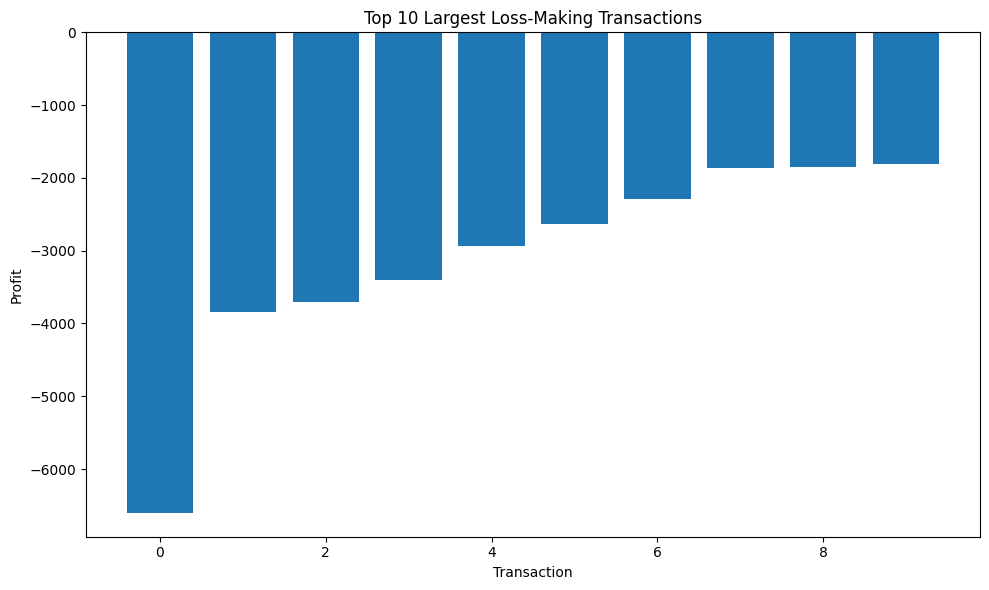

In [34]:
top_losses = df.nsmallest(10, "Profit")

plt.figure(figsize=(10,6))

plt.bar(
    range(len(top_losses)),
    top_losses["Profit"]
)

plt.title("Top 10 Largest Loss-Making Transactions")
plt.xlabel("Transaction")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [ ]:
# Key Business Insights

### 1. Technology leads category performance
Technology generated the highest sales of $836,154.03 and the highest profit of $145,451.98 among the three product categories.

### 2. West is the strongest region by sales and profit
The West region generated $725,255.64 in sales and $108,328.84 in profit, both the highest among the four regions.

### 3. Consumer is the largest customer segment
The Consumer segment generated approximately $1.16 million in sales and $134,004.47 in profit, making it the largest segment by sales, profit, and quantity.

### 4. Some high-sales products are not profitable
The Tables sub-category generated $206,964.53 in sales but recorded a total loss of $17,725.48. Bookcases and Supplies also recorded negative total profit.

### 5. Higher discounts are associated with lower profitability
The correlation between Discount and Profit was -0.22, indicating a weak negative linear relationship. Every discount level from 30% to 80% had negative total profit in this dataset.

### 6. High-value transactions can still generate losses
The highest-sales transaction generated $22,638.48 in sales but produced a loss of $1,811.08. The largest individual loss was $6,599.98 on a Machines transaction with a 70% discount.

## Overall Conclusion

The analysis indicates a weak negative relationship between discount and profit.